### Libs import

In [1]:
# === Imports & базовые настройки ===
import os
import math
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

def set_seed(seed: int = 42) -> None:
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cpu


### Dataloading

In [2]:
PATH = "data/binance/fut/hour"
RESAMPLE_INTERVAL = "4H"         # например: '1H', '4H', '1D'
MAX_TICKERS = 60
WINDOW_SIZE = 100                # длина окна для LSTM
TEST_LEN = 800                   # последние TEST_LEN примеров — тест
VAL_LEN = 800                    # перед тестом — валидация


full_data = pd.read_csv('full_data.csv', index_col='openTime')

RET_COLS = []
LEARNING_COLS = []

for col in full_data:
    if '_ret' in col:
        RET_COLS.append(col)
    else:
        LEARNING_COLS.append(col)

## 2) Генерация окон (X) и таргета (y)

- `X[t]` = окно длины `WINDOW_SIZE` из **признаков** (`feature_cols`)  
- `y[t]` = вектор **следующих доходностей** по активам (`ret_cols`)  

Важно: для корректного turnover-пенальти ниже мы оставляем `shuffle=False` и разделяем данные **по времени**.


In [3]:
from sklearn.preprocessing import StandardScaler

def make_windows(df: pd.DataFrame, feature_cols: list[str], ret_cols: list[str], window_size: int):
    X_list, y_list, idx_list = [], [], []
    values_X = df[feature_cols].values.astype(np.float32)
    values_y = df[ret_cols].values.astype(np.float32)

    for t in range(window_size, len(df)):
        X_list.append(values_X[t-window_size:t, :])
        y_list.append(values_y[t, :])          # доходности следующего шага
        idx_list.append(df.index[t])

    X = np.stack(X_list)  # (n_samples, window, n_features)
    y = np.stack(y_list)  # (n_samples, n_assets)
    idx = pd.Index(idx_list)
    return X, y, idx

X, y, idx = make_windows(full_data, LEARNING_COLS, RET_COLS, WINDOW_SIZE)
print("X:", X.shape, "y:", y.shape)

# --- train/val/test split по времени ---
n = X.shape[0]
test_len = min(TEST_LEN, n//5)
val_len = min(VAL_LEN, n//5)

train_end = n - (val_len + test_len)
val_end = n - test_len

X_train, y_train, idx_train = X[:train_end], y[:train_end], idx[:train_end]
X_val, y_val, idx_val = X[train_end:val_end], y[train_end:val_end], idx[train_end:val_end]
X_test, y_test, idx_test = X[val_end:], y[val_end:], idx[val_end:]

print("train:", X_train.shape, y_train.shape)
print("val:  ", X_val.shape, y_val.shape)
print("test: ", X_test.shape, y_test.shape)

# --- scaling фичей (fit только на train) ---
scaler = StandardScaler()
# фитим на всех временных шагах обучающего набора
scaler.fit(X_train.reshape(-1, X_train.shape[-1]))

def scale_X(X_):
    Xs = scaler.transform(X_.reshape(-1, X_.shape[-1])).reshape(X_.shape).astype(np.float32)
    return Xs

X_train = scale_X(X_train)
X_val   = scale_X(X_val)
X_test  = scale_X(X_test)

# sanity check
np.isfinite(X_train).all(), np.isfinite(y_train).all()


X: (7451, 100, 567) y: (7451, 63)
train: (5851, 100, 567) (5851, 63)
val:   (800, 100, 567) (800, 63)
test:  (800, 100, 567) (800, 63)


(np.True_, np.True_)

## 3) DataLoader

In [4]:
class WindowDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        return self.X[i], self.y[i]

BATCH_SIZE = 256

train_loader = DataLoader(WindowDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
val_loader   = DataLoader(WindowDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(WindowDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

xb, yb = next(iter(train_loader))
print("batch:", xb.shape, yb.shape)

batch: torch.Size([256, 100, 567]) torch.Size([256, 63])


## 4) Модель: LSTM → веса портфеля

Модель принимает окно `WINDOW_SIZE × n_features` и выдаёт `n_assets` скалярных весов.

Мы будем **нормализовать веса внутри loss**, чтобы в них была:
- долларовая нейтральность (sum(w)=0),
- L1-нормировка (sum(|w|)=1).


In [5]:
class LSTMPortfolio(nn.Module):
    def __init__(self, n_features: int, n_assets: int, hidden: int = 32,
                 num_layers: int = 2, dropout: float = 0.5):
        super().__init__()
        self.in_dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            n_features, hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.head = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_assets),
        )

    def forward(self, x):
        x = self.in_dropout(x)           # (B, T, F)
        out, _ = self.lstm(x)
        h_last = out[:, -1, :]
        logits = self.head(h_last)
        return logits

n_features = X_train.shape[-1]
n_assets = y_train.shape[-1]

model = LSTMPortfolio(
    n_features=n_features, n_assets=n_assets).to(device)
LR = 3e-4
WEIGHT_DECAY = 1e-3
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# sum(p.numel() for p in model.parameters()) / 1e6


## 5) Пользовательская функция потерь

Мы хотим учить модель **не на MSE по доходностям**, а сразу на то, что важно для стратегии.

### Пример: максимизация Sharpe с штрафом за turnover
1) Получаем веса `w_t` (после нейтрализации + L1-нормировки)  
2) Доходность портфеля `p_t = Σ_i w_{t,i} · r_{t,i}`  
3) Sharpe `S = mean(p) / (std(p)+ε)` → **loss = -S**  
4) Turnover `TO = mean(|w_t - w_{t-1}|)` → добавляем `λ · TO`  

> Для демонстрации достаточно. Если захотите — легко добавить constraints (max_weight, sector-neutral, risk parity и т.д.).


In [6]:
def normalize_weights(raw_w: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    # raw_w: (B, N)
    w = raw_w - raw_w.mean(dim=1, keepdim=True)                 # dollar-neutral: sum(w)=0
    w = w / (w.abs().sum(dim=1, keepdim=True) + eps)            # L1 norm: sum(|w|)=1
    return w

class SharpeTurnoverLoss(nn.Module):
    def __init__(self, turnover_weight: float = 2.0, eps: float = 1e-8):
        super().__init__()
        self.turnover_weight = turnover_weight
        self.eps = eps

    def forward(self, raw_w: torch.Tensor, r: torch.Tensor):
        """raw_w: (B, N_assets), r: (B, N_assets)"""
        w = normalize_weights(raw_w, eps=self.eps)
        pnl = (w * r).sum(dim=1)  # (B,)

        mean = pnl.mean()
        std = pnl.std(unbiased=False)
        sharpe = mean / (std + self.eps)

        if w.shape[0] > 1:
            turnover = (w[1:] - w[:-1]).abs().sum(axis=1).mean()
        else:
            turnover = torch.tensor(0.0, device=w.device)

        # Итоговый loss
        loss = -sharpe + self.turnover_weight * turnover

        aux = {
            "loss": loss.detach().item(),
            "sharpe": sharpe.detach().item(),
            "turnover": turnover.detach().item(),
            "mean_pnl": mean.detach().item(),
            "vol_pnl": std.detach().item()
        }
        return loss, aux

# baseline (для сравнения): учим предсказывать сами доходности (не стратегия)
mse_loss = nn.MSELoss()

loss_fn = SharpeTurnoverLoss(turnover_weight=0.7).to(device)


## 6) Обучение

Для лайва обычно достаточно 5–15 эпох, чтобы показать динамику метрик и получить осмысленный график PnL.


In [7]:
LR = 3e-4
WEIGHT_DECAY = 1e-5
EPOCHS = 30
GRAD_CLIP = 1.0

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def run_epoch(model, loader, train: bool):
    model.train(train)
    total_loss = 0.0
    n_batches = 0
    agg = {"sharpe": 0.0, "mean_pnl": 0.0, "vol_pnl": 0.0}

    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device)

        if train:
            optimizer.zero_grad(set_to_none=True)

        raw_w = model(Xb)
        loss, aux = loss_fn(raw_w, yb)

        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

        total_loss += aux["loss"]
        for k in agg:
            agg[k] += aux[k]
        n_batches += 1

    for k in agg:
        agg[k] /= max(1, n_batches)
    return total_loss / max(1, n_batches), agg

history = {"train": [], "val": []}
best_val_sharpe = -np.inf
best_state_dict = None
patience = 5
best_val_sharpe = -np.inf
patience_counter = 0
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_aux = run_epoch(model, train_loader, train=True)
    va_loss, va_aux = run_epoch(model, val_loader, train=False)
    val_sharpe = va_aux["sharpe"]
    if val_sharpe > best_val_sharpe:
        best_val_sharpe = val_sharpe
        best_state_dict = model.state_dict().copy()
        patience_counter = 0
        torch.save(best_state_dict, 'best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    history["train"].append({"loss": tr_loss, **tr_aux})
    history["val"].append({"loss": va_loss, **va_aux})

    print(f"Epoch {epoch:03d} | train loss={tr_loss:.4f}, sharpe={tr_aux['sharpe']:.3f} "
          f"| val loss={va_loss:.4f}, sharpe={va_aux['sharpe']:.3f}")


Epoch 001 | train loss=0.6795, sharpe=0.013 | val loss=0.1525, sharpe=-0.022
Epoch 002 | train loss=0.5908, sharpe=-0.001 | val loss=0.1008, sharpe=-0.020
Epoch 003 | train loss=0.5145, sharpe=-0.005 | val loss=0.0720, sharpe=-0.018
Epoch 004 | train loss=0.4352, sharpe=0.012 | val loss=0.0576, sharpe=-0.017
Epoch 005 | train loss=0.3888, sharpe=0.011 | val loss=0.0499, sharpe=-0.016
Epoch 006 | train loss=0.3354, sharpe=0.019 | val loss=0.0431, sharpe=-0.016
Epoch 007 | train loss=0.3170, sharpe=0.008 | val loss=0.0379, sharpe=-0.014
Epoch 008 | train loss=0.2799, sharpe=0.016 | val loss=0.0342, sharpe=-0.013
Epoch 009 | train loss=0.2555, sharpe=0.015 | val loss=0.0319, sharpe=-0.013
Epoch 010 | train loss=0.2371, sharpe=0.010 | val loss=0.0294, sharpe=-0.013
Epoch 011 | train loss=0.2154, sharpe=0.014 | val loss=0.0275, sharpe=-0.012
Epoch 012 | train loss=0.2013, sharpe=0.011 | val loss=0.0250, sharpe=-0.011
Epoch 013 | train loss=0.1846, sharpe=0.015 | val loss=0.0235, sharpe=-0.0

In [8]:
print(device)
print(X_train.shape)
print(X_train.dtype)
print(torch.cuda.is_available())

cpu
(5851, 100, 567)
float32
False


In [9]:
model.load_state_dict(best_state_dict)
print("Loaded best model with val Sharpe:", best_val_sharpe)

Loaded best model with val Sharpe: -0.0043296171352267265


## 7) Графики обучения

<Axes: >

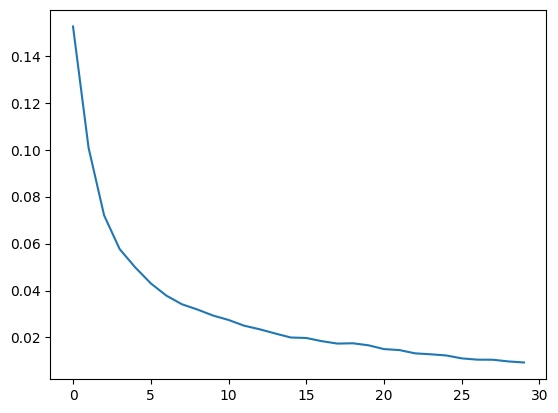

In [10]:
pd.DataFrame(history["val"])['loss'].plot()

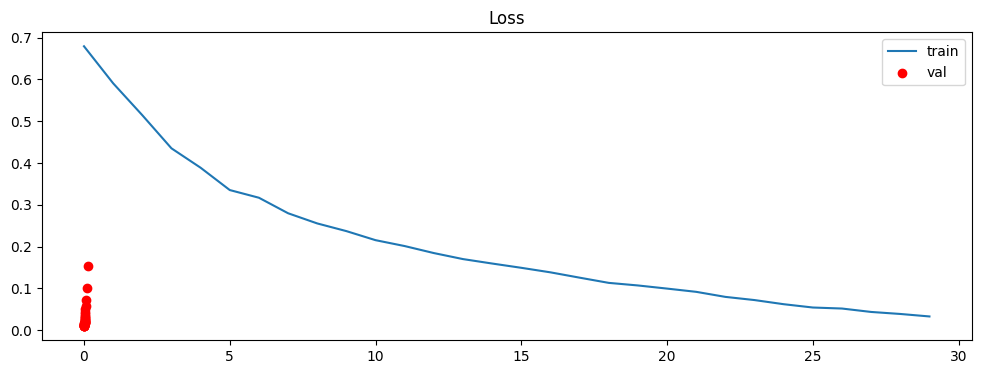

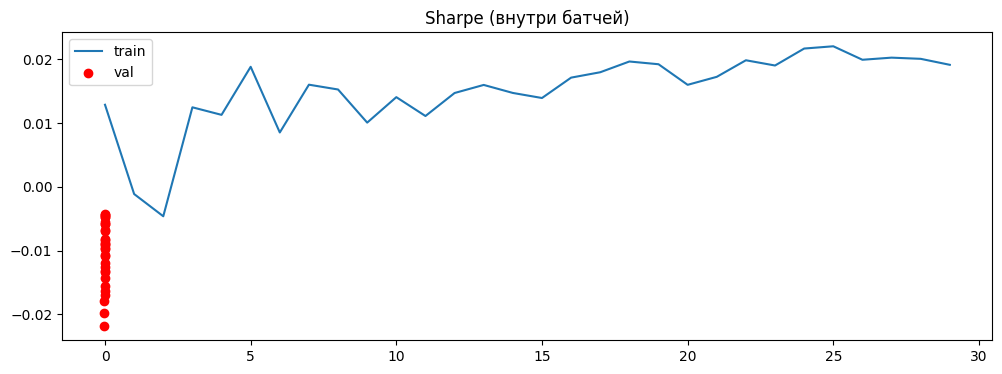

In [11]:
hist_train = pd.DataFrame(history["train"])
hist_val   = pd.DataFrame(history["val"])

plt.figure(figsize=(12,4))
plt.plot(hist_train["loss"], label="train")
plt.scatter(hist_val["loss"].values, hist_val["loss"], label="val", color='r')
plt.title("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(hist_train["sharpe"], label="train")
plt.scatter(hist_val["sharpe"].values, hist_val["sharpe"], label="val", color='r')
plt.title("Sharpe (внутри батчей)")
plt.legend()
plt.show()

# plt.figure(figsize=(12,4))
# plt.plot(hist_train["turnover"], label="train")
# plt.scatter(hist_val["turnover"].index, hist_val["turnover"], label="val", color='r')
# plt.title("Turnover (внутри батчей)")
# plt.legend()
# plt.show()


## 8) Мини-бэктест на тестовом периоде

Считаем:
- серию доходностей портфеля `p_t`
- cumulative PnL (простая сумма доходностей)
- Sharpe и max drawdown на тесте  
- средний turnover (по времени)

> Это не “полный” бэктест (нет комиссий/слиппеджа), но для семинара — отлично.


In [12]:
def backtest(model, X, y, periods_per_year=365*6):  # для 4H данных
  model.eval()
  with torch.no_grad():
    raw = model(torch.Tensor(X).to(device)).cpu().numpy()

  w = pd.DataFrame(raw)
  w = w.sub(w.mean(axis=1), axis=0)
  w = w.div(w.abs().sum(axis=1), axis=0)
  pnl = (w.values * y).sum(axis=1)
  pnl = pd.Series(pnl)

  cum_pnl = pnl.cumsum()

  sharpe = pnl.mean() / (pnl.std(ddof=0) + 1e-8)
  sharpe_ann = sharpe * np.sqrt(periods_per_year)


  rolling_max = cum_pnl.cummax()
  drawdown = cum_pnl - rolling_max
  max_dd = drawdown.min()

  turnover = w.diff().abs().sum(axis=1).mean()

  return {
      "pnl": pnl,
      "cum_pnl": cum_pnl,
      "sharpe": sharpe,
      "sharpe_ann": sharpe_ann,
      "max_drawdown": max_dd,
      "mean_turnover": turnover
  }



In [13]:
bt_val = backtest(model, X_val, y_val)
bt_test = backtest(model, X_test, y_test)

print("VAL Sharpe ann:", bt_val["sharpe_ann"])
print("TEST Sharpe ann:", bt_test["sharpe_ann"])
print("TEST Max DD:", bt_test["max_drawdown"])
print("TEST Turnover:", bt_test["mean_turnover"])

VAL Sharpe ann: 2.350154396200834
TEST Sharpe ann: 1.7877053846922313
TEST Max DD: -0.047659136
TEST Turnover: 0.0071712695


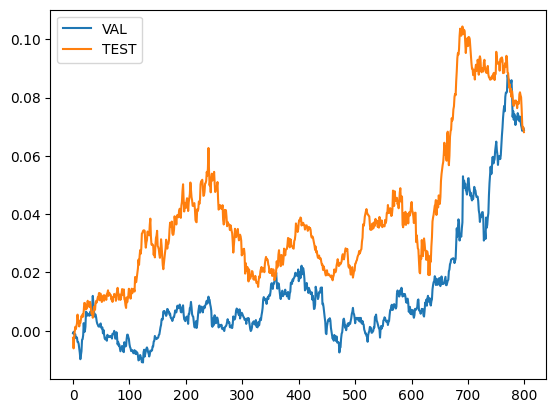

In [14]:
bt_val = backtest(model, X_val, y_val)
bt_test = backtest(model, X_test, y_test)

plt.plot(bt_val["cum_pnl"], label="VAL")
plt.plot(bt_test["cum_pnl"], label="TEST")
plt.legend()
plt.show()

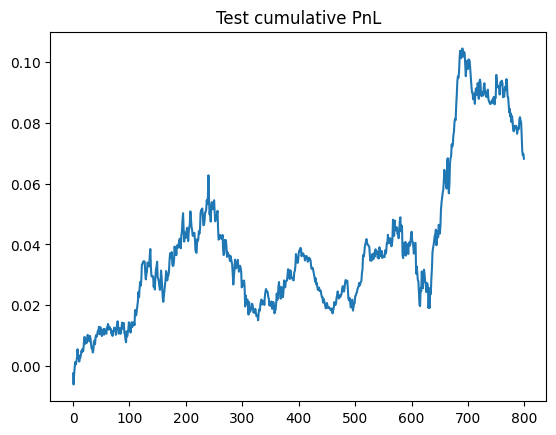

In [15]:
bt_test["cum_pnl"].plot()
plt.title("Test cumulative PnL")
plt.show()

## 10) Сохранение модели и артефактов

Сохраняем:
- веса модели (`state_dict`)
- scaler
- конфиг гиперпараметров
- итоговые метрики на тесте


In [16]:
torch.save(model.state_dict(), "tot_best_lstm_state_dict.pth")